In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [2]:
# Make the corner plot for the MCMC results
system_name = 'J2145'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'z', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [3]:
samples

,chi2,z,vel_disp,x,y,ellip,pa
0,1.793772,0.264000,221.6357,0.715643,1.147329,0.596321,32.09011
1,7.459991,0.266255,221.6432,0.710416,1.147437,0.598595,32.12867
2,3.319240,0.262673,221.5628,0.713590,1.147695,0.592399,32.08257
3,4.427500,0.266495,221.5564,0.714048,1.142556,0.590429,32.07697
4,5.039069,0.264053,221.5238,0.712596,1.144396,0.589972,32.04703
...,...,...,...,...,...,...,...
1059,4.261656,0.249693,220.5896,0.709688,1.159483,0.607265,32.09419
1060,3.666624,0.249703,220.5432,0.709736,1.158239,0.603889,32.11169
1061,3.087922,0.253024,220.6048,0.714732,1.153402,0.599470,32.15362
1062,9.437903,0.248819,220.6142,0.712470,1.150520,0.597810,32.17312


In [4]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [5]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

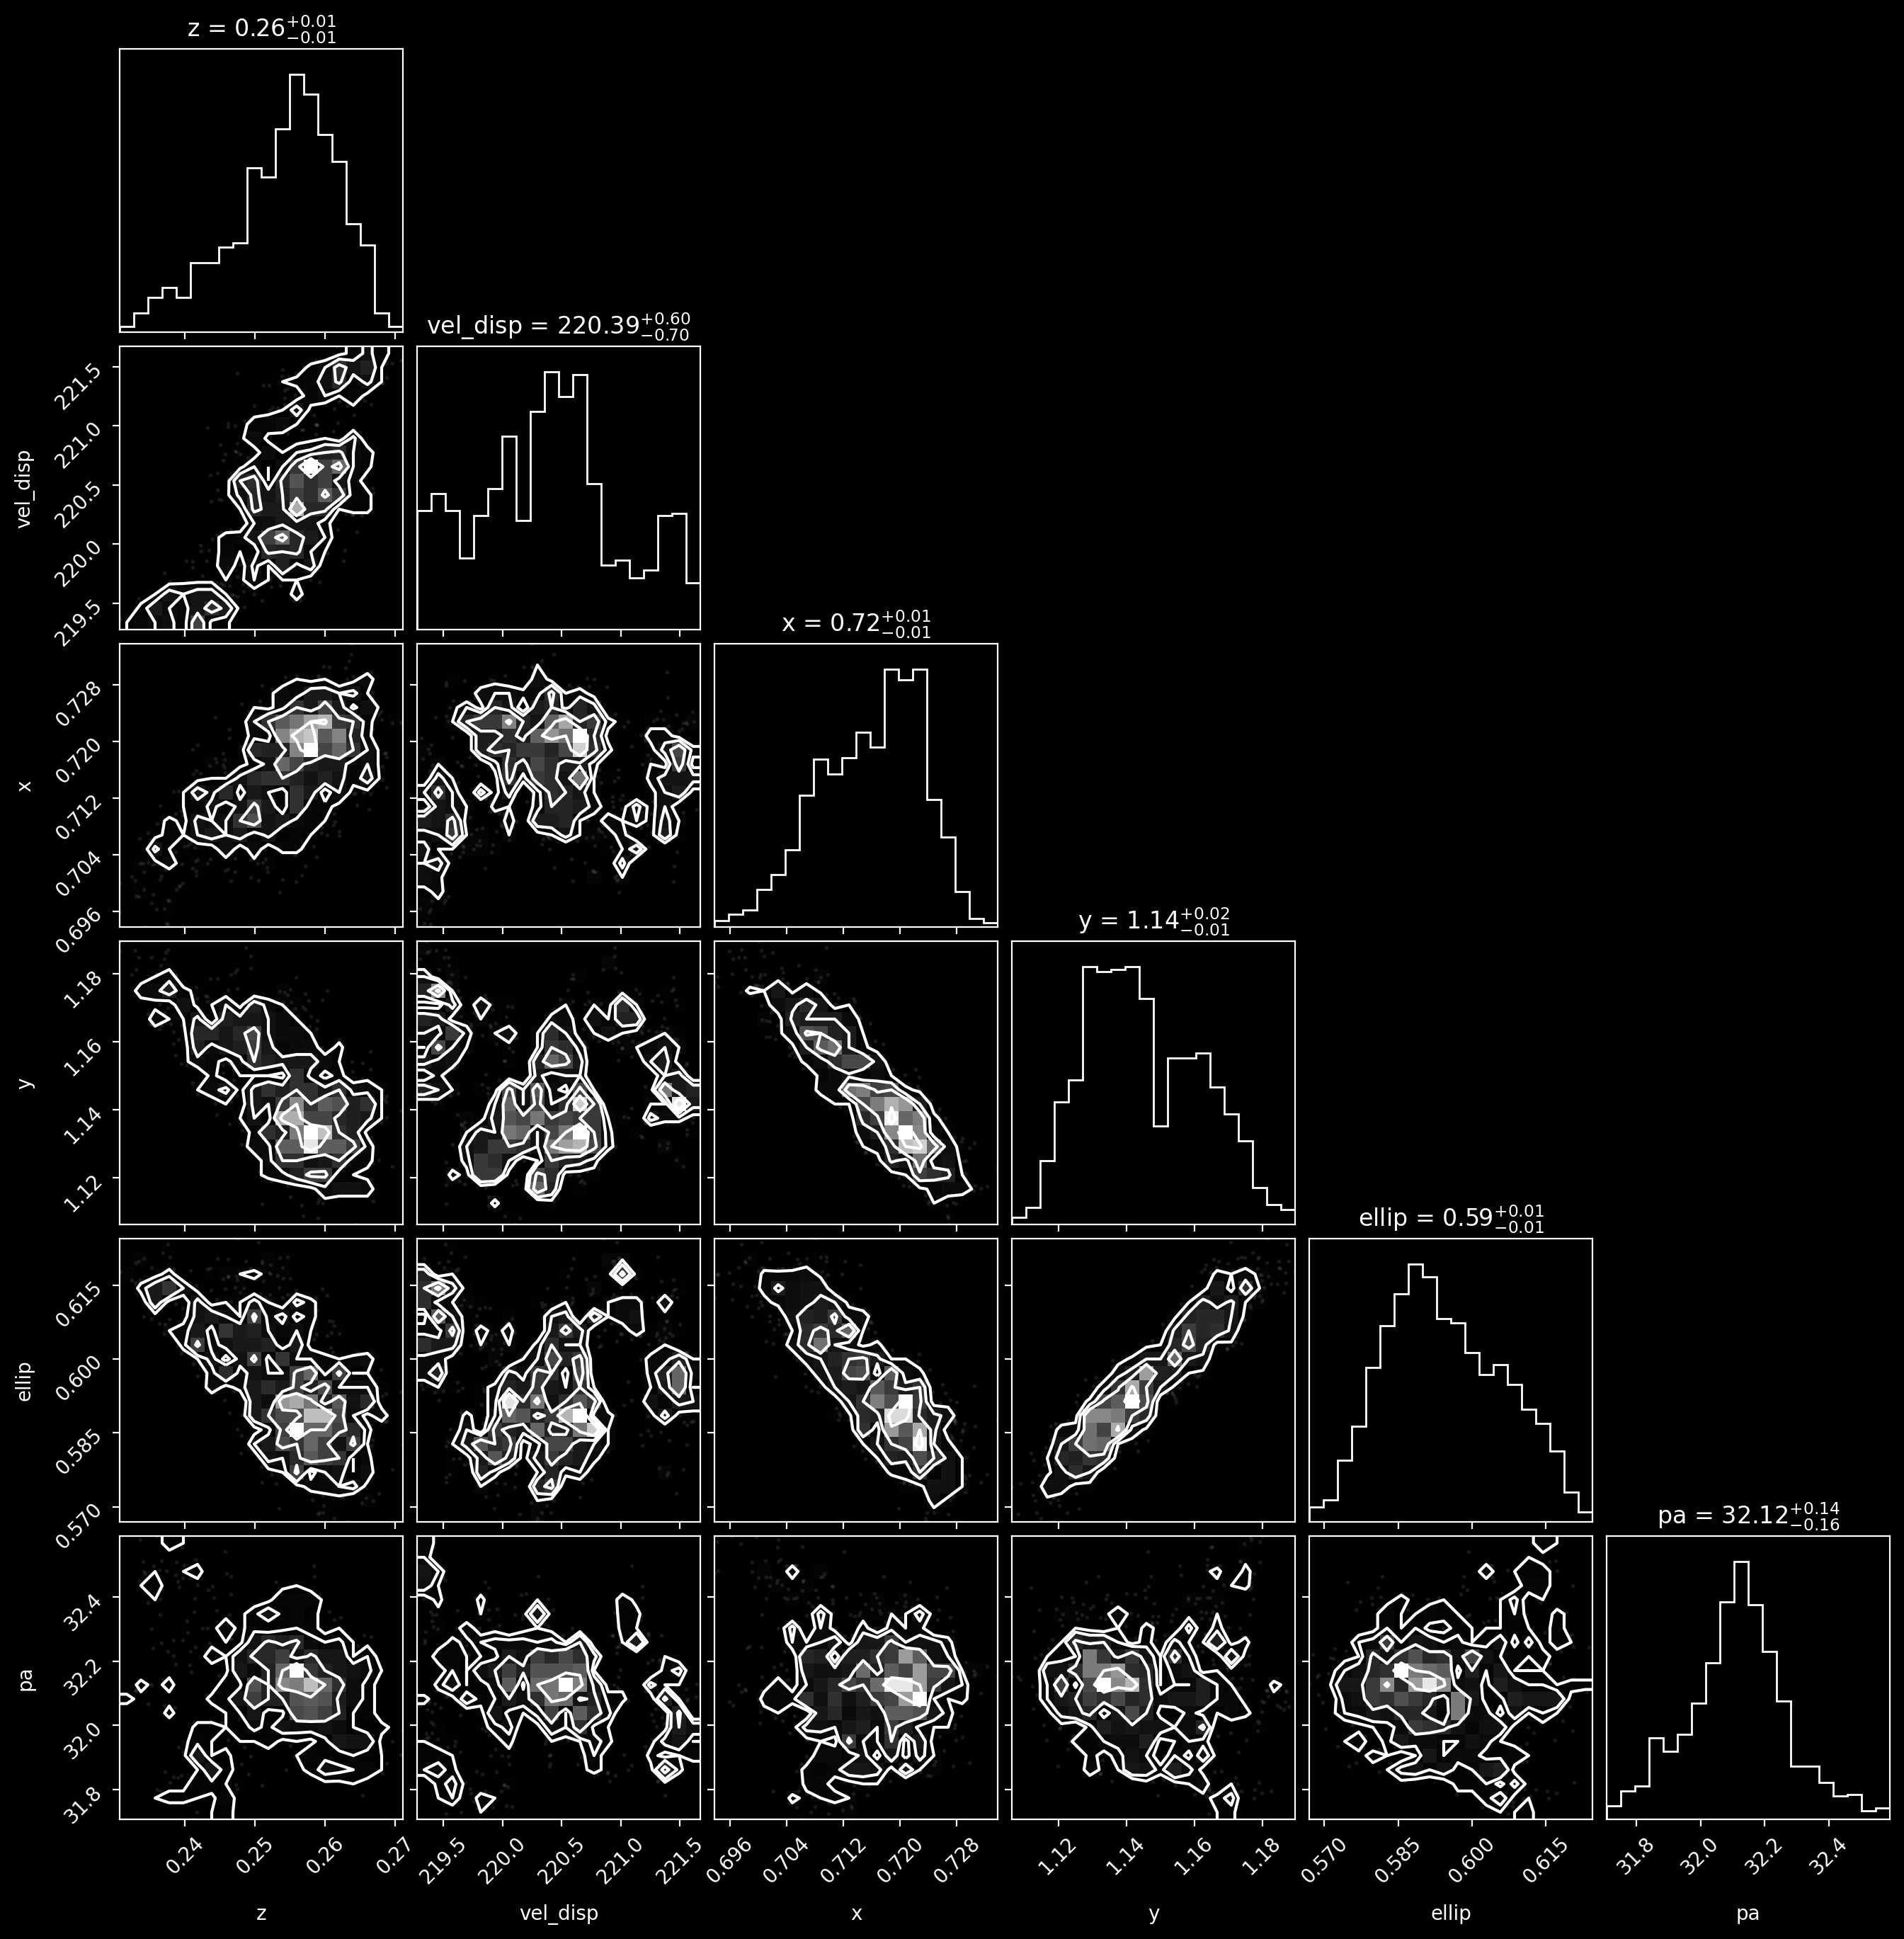

In [6]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['z', 'vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')